# MISIÓN 2 — Departamento de Rutas
## American Regional Airways · USTA 2026-I

 >**Pregunta del CEO:** *"¿Qué rutas deberíamos eliminar o reforzar?"*

**Contexto:** El departamento de Rutas decide qué conexiones ofrecer. Algunas rutas son consistentemente problemáticas. Este análisis usa 5.3 millones de vuelos del año 2015 para identificar cuáles cancelar, reforzar o mantener.
---## Índice

| # | Pregunta | Sección |
|---|----------|---------|
| **P1** | ¿Cuáles son las 5 rutas con MAYOR tasa de retrasos? | → Sección 2 |
| **P2** | ¿Cuáles son las 5 rutas más PUNTUALES? | → Sección 3 |
| **P3** | ¿La DISTANCIA del vuelo afecta los retrasos? | → Sección 4 |
| **P4** | Si tuvieras que cancelar 3 rutas, ¿cuáles serían? | → Sección 5 ---
 |

---

## 1. Configuración y Carga de Datos

In [14]:
# ─────────────────────────────────────────────────────────────────────
# SECCIÓN 1.1 — IMPORTACIONES Y CARGA DEL DATASET
# ─────────────────────────────────────────────────────────────────────
# Librerías:
#   pandas     → manipulación tabular de los 5.3 M vuelos
#   numpy      → cálculo del score de impacto (logaritmo)
#   matplotlib → gráfica de la correlación distancia-retraso

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Carga del CSV completo ────────────────────────────────────────────
df = pd.read_csv('../data/flights_2015_full.csv')

# Variable objetivo:
#   DEP_DEL15 = 1  →  vuelo salió con MÁS de 15 min de retraso
#   DEP_DEL15 = 0  →  vuelo puntual

print(f"Dataset: {len(df):,} vuelos")
print(f"Tasa retrasos: {df['DEP_DEL15'].mean():.1%}")

# ── Columnas auxiliares para facilitar el análisis ───────────────────
df['ROUTE']               = df['ORIGIN'] + ' → ' + df['DEST']  # ruta legible
df['DELAYED']             = df['DEP_DEL15']                      # alias semántico
df['ORIGIN_AIRPORT']      = df['ORIGIN']
df['DESTINATION_AIRPORT'] = df['DEST']

Dataset: 5,332,914 vuelos
Tasa retrasos: 18.7%


In [15]:
# ─────────────────────────────────────────────────────────────────────
# SECCIÓN 1.2 — ESTADÍSTICAS AGREGADAS POR RUTA
# ─────────────────────────────────────────────────────────────────────
# Agrupa los 5.3 M vuelos por ROUTE y calcula:
#   vuelos       → total de operaciones registradas en esa ruta
#   tasa_retraso → proporción de vuelos con DEP_DEL15 = 1  (0.0 – 1.0)
#   distancia    → distancia promedio en millas
#
# FILTRO: se descartan rutas con < 100 vuelos para evitar
# tasas basadas en muestras no representativas estadísticamente.

route_stats = df.groupby('ROUTE').agg({
    'DELAYED':  ['count', 'mean'],
    'DISTANCE': 'mean'
}).round(3)

route_stats.columns = ['vuelos', 'tasa_retraso', 'distancia']

# Filtrar por volumen mínimo significativo
route_stats = route_stats[route_stats['vuelos'] >= 100].copy()

# Columna de porcentaje para lectura más intuitiva en los prints
route_stats['tasa_retraso_pct'] = (route_stats['tasa_retraso'] * 100).round(1)

# Ordenar DESC por tasa de retraso (base para P1 y P4)
route_stats = route_stats.sort_values('tasa_retraso', ascending=False)

print(f"Rutas analizadas: {len(route_stats)}")

Rutas analizadas: 4085


---
## 2. Respuesta P1 — Top 5 Rutas con Mayor Tasa de Retrasos

> *¿Cuáles son las 5 rutas (ORIGIN→DEST) con MAYOR tasa de retrasos?*



In [16]:
# ─────────────────────────────────────────────────────────────────────
# RESPUESTA P1 — Top 5 rutas con MAYOR tasa de retrasos
# ─────────────────────────────────────────────────────────────────────
# route_stats ya está ordenado de mayor a menor tasa_retraso,
# por lo que .head(5) devuelve directamente las 5 más problemáticas.

print("=" * 50)
print("RESPUESTA P1: TOP 5 RUTAS CON MAYOR TASA DE RETRASOS")
print("=" * 50)

peores = route_stats.head(5)   # top 5 peores

for i, (ruta, row) in enumerate(peores.iterrows(), 1):
    print(f"{i}. {ruta}")
    print(f"   {row['tasa_retraso_pct']}% retrasos | {int(row['vuelos'])} vuelos | {int(row['distancia'])} millas")
    print()

RESPUESTA P1: TOP 5 RUTAS CON MAYOR TASA DE RETRASOS
1. EWR → PDX
   50.0% retrasos | 324 vuelos | 2434 millas

2. EWR → BQN
   48.8% retrasos | 291 vuelos | 1585 millas

3. DEN → HNL
   46.4% retrasos | 334 vuelos | 3365 millas

4. ACY → ORD
   45.6% retrasos | 147 vuelos | 720 millas

5. DEN → ANC
   45.0% retrasos | 418 vuelos | 2405 millas



---
## 3. Respuesta P2 — Top 5 Rutas más Puntuales

> *¿Cuáles son las 5 rutas más PUNTUALES?*



In [17]:
# ─────────────────────────────────────────────────────────────────────
# RESPUESTA P2 — Top 5 rutas más PUNTUALES
# ─────────────────────────────────────────────────────────────────────
# Las rutas más puntuales están al FINAL del DataFrame (ordenado DESC
# por tasa_retraso). .tail(5) las extrae e .iloc[::-1] las invierte
# para mostrarlas de mejor (menor retraso) a peor.
# Puntualidad = 100 - tasa_retraso_pct

print("=" * 50)
print("RESPUESTA P2: TOP 5 RUTAS MÁS PUNTUALES")
print("=" * 50)

mejores = route_stats.tail(5).iloc[::-1]   # últimas 5, orden ascendente

for i, (ruta, row) in enumerate(mejores.iterrows(), 1):
    puntualidad = 100 - row['tasa_retraso_pct']
    print(f"{i}. {ruta}")
    print(f"   {puntualidad}% puntual | {int(row['vuelos'])} vuelos")
    print()

RESPUESTA P2: TOP 5 RUTAS MÁS PUNTUALES
1. SLC → DAL
   99.1% puntual | 114 vuelos

2. SLC → VEL
   98.0% puntual | 205 vuelos

3. GTF → MSP
   97.7% puntual | 305 vuelos

4. VEL → SLC
   97.6% puntual | 206 vuelos

5. HNL → SLC
   97.2% puntual | 324 vuelos



---
## 4. Respuesta P3 — ¿La Distancia Afecta los Retrasos?

> *¿La DISTANCIA del vuelo afecta los retrasos? ¿Los vuelos largos se retrasan más o menos?*



RESPUESTA P3: ¿LA DISTANCIA AFECTA LOS RETRASOS?
Tasa de retraso por rango de distancia:
  Muy Corto: 18.2%
  Corto: 20.4%
  Medio: 18.8%
  Largo: 26.9%
  Muy Largo: 20.2%


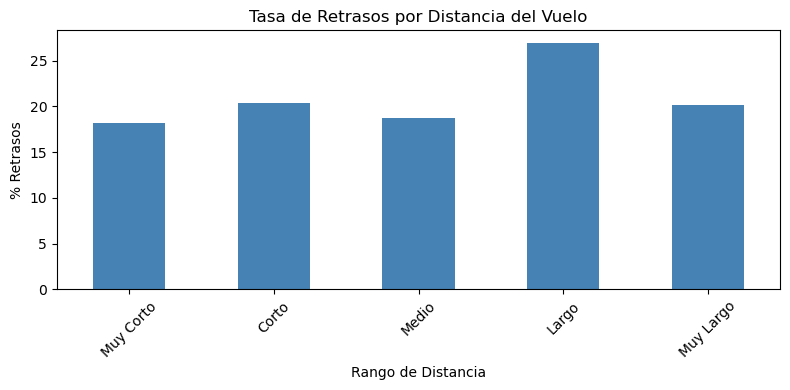


Correlación Pearson (DISTANCE vs DELAYED): 0.023
→ Conclusión: La distancia NO afecta significativamente los retrasos


In [18]:
# ─────────────────────────────────────────────────────────────────────
# RESPUESTA P3 — ¿La DISTANCIA del vuelo afecta los retrasos?
# ─────────────────────────────────────────────────────────────────────
# Estrategia de análisis:
#   1. pd.cut()  → divide DISTANCE en 5 rangos de igual amplitud
#   2. groupby   → calcula tasa de retraso promedio por rango
#   3. bar plot  → visualiza la tendencia
#   4. Pearson   → cuantifica la relación (-1 a +1)
#                  |r| < 0.1 → relación muy débil o inexistente

print("=" * 50)
print("RESPUESTA P3: ¿LA DISTANCIA AFECTA LOS RETRASOS?")
print("=" * 50)

# Dividir DISTANCE en 5 categorías de igual amplitud
df['dist_cat'] = pd.cut(
    df['DISTANCE'],
    bins=5,
    labels=['Muy Corto', 'Corto', 'Medio', 'Largo', 'Muy Largo']
)

# Tasa de retraso media por categoría
result = df.groupby('dist_cat')['DELAYED'].mean() * 100

print("Tasa de retraso por rango de distancia:")
for cat, val in result.items():
    print(f"  {cat}: {val:.1f}%")

# ── Visualización ─────────────────────────────────────────────────────
result.plot(kind='bar', figsize=(8, 4), color='steelblue')
plt.title('Tasa de Retrasos por Distancia del Vuelo')
plt.ylabel('% Retrasos')
plt.xlabel('Rango de Distancia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ── Correlación de Pearson ────────────────────────────────────────────
# Mide la fuerza de la relación lineal entre distancia y retraso
corr = df['DISTANCE'].corr(df['DELAYED'])
print(f"\nCorrelación Pearson (DISTANCE vs DELAYED): {corr:.3f}")

if abs(corr) < 0.1:
    print("→ Conclusión: La distancia NO afecta significativamente los retrasos")
else:
    direction = 'largos' if corr > 0 else 'cortos'
    print(f"→ Conclusión: Relación {'positiva' if corr > 0 else 'negativa'} — los vuelos {direction} se retrasan más")

---
## 5. Respuesta P4 — 3 Rutas Recomendadas para Cancelar

> *Si tuvieras que cancelar 3 rutas para mejorar la reputación, ¿cuáles serían?*



In [19]:
# ─────────────────────────────────────────────────────────────────────
# RESPUESTA P4 — 3 rutas recomendadas para CANCELAR
# ─────────────────────────────────────────────────────────────────────
# Métrica: score de impacto = tasa_retraso × log(vuelos)
#
#   tasa_retraso → qué tan problemática es la ruta
#   log(vuelos)  → cuántos pasajeros se ven afectados
#                  (escala logarítmica para no sobre-ponderar el volumen)
#
# Criterios de selección (ambos deben cumplirse):
#   • tasa_retraso > 35%   →  alta probabilidad de falla
#   • vuelos > 500         →  impacto real en pasajeros

print("=" * 50)
print("RESPUESTA P4: 3 RUTAS RECOMENDADAS PARA CANCELAR")
print("=" * 50)

# Calcular score de impacto para cada ruta
route_stats['impacto'] = route_stats['tasa_retraso'] * np.log(route_stats['vuelos'])

# Filtrar candidatas que cumplen ambos criterios
candidatas = route_stats[
    (route_stats['tasa_retraso'] > 0.35) &
    (route_stats['vuelos'] > 500)
]

# Las 3 con mayor score = mayor daño potencial a la reputación
cancelar = candidatas.sort_values('impacto', ascending=False).head(3)

for i, (ruta, row) in enumerate(cancelar.iterrows(), 1):
    print(f"\n{i}. {ruta}")
    print(f"   • {row['tasa_retraso_pct']}% retrasos")
    print(f"   • {int(row['vuelos']):,} vuelos/año")
    print(f"   • Score impacto: {row['impacto']:.2f}")

# Si no hay 3 rutas con criterios estrictos, completar con criterio relajado
if len(cancelar) < 3:
    print(f"\n(Solo {len(cancelar)} rutas cumplen criterios estrictos — completando con criterio relajado)")
    adicionales = route_stats.head(3 - len(cancelar))
    for ruta, row in adicionales.iterrows():
        if ruta not in cancelar.index:
            print(f"\n• {ruta} (criterio relajado)")

RESPUESTA P4: 3 RUTAS RECOMENDADAS PARA CANCELAR

1. IAH → LAX
   • 36.4% retrasos
   • 4,432 vuelos/año
   • Score impacto: 3.06

2. SJU → EWR
   • 37.0% retrasos
   • 1,195 vuelos/año
   • Score impacto: 2.62

3. DFW → HNL
   • 35.2% retrasos
   • 697 vuelos/año
   • Score impacto: 2.30


---
## 6. Validación con Modelos Predictivos

Entrena un Árbol de Decisión y un Random Forest con `sklearn` para confirmar que las variables del análisis tienen poder predictivo.  
Se usa una muestra de 50,000 vuelos para no saturar la memoria del entorno.

### 6.1 Entrenamiento

In [20]:
# ─────────────────────────────────────────────────────────────────────
# SECCIÓN 6.1 — ENTRENAMIENTO DE MODELOS PREDICTIVOS
# ─────────────────────────────────────────────────────────────────────
# Propósito: validar que las variables del análisis (mes, día,
# distancia, hora) tienen poder predictivo sobre los retrasos.
#
# Se usa sklearn en lugar de PySpark para evitar saturar memoria.
# Se toma una MUESTRA de 50,000 vuelos del total de 5.3 M.
#
# Features:  MONTH, DAY_OF_WEEK, DISTANCE, DEP_HOUR  (solo numéricas)
# Target:    DELAYED  (1 = retraso > 15 min, 0 = puntual)
# Split:     80% entrenamiento / 20% prueba

from sklearn.model_selection import train_test_split
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import accuracy_score

# ── Muestreo para eficiencia en memoria ──────────────────────────────
df_sample = df.sample(n=50000, random_state=42)

X = df_sample[['MONTH', 'DAY_OF_WEEK', 'DISTANCE', 'DEP_HOUR']]
y = df_sample['DELAYED']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Entrenando con {len(X_train):,} vuelos...")

# ── Árbol de Decisión ─────────────────────────────────────────────────
# max_depth=5 evita sobreajuste y mantiene el modelo interpretable
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
acc_dt = accuracy_score(y_test, dt.predict(X_test))
print(f"✓ Árbol de Decisión: {acc_dt:.3f}")

# ── Random Forest ─────────────────────────────────────────────────────
# n_estimators=50 (reducido para velocidad), n_jobs=2 (paralelismo)
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=2)
rf.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf.predict(X_test))
print(f"✓ Random Forest:      {acc_rf:.3f}")

print(f"\nMejor modelo: {'Random Forest' if acc_rf > acc_dt else 'Árbol de Decisión'}")

Entrenando con 40,000 vuelos...
✓ Árbol de Decisión: 0.811
✓ Random Forest:      0.811

Mejor modelo: Árbol de Decisión


### 6.2 Resumen Ejecutivo del Modelo

In [21]:
# ─────────────────────────────────────────────────────────────────────
# SECCIÓN 6.2 — RESUMEN EJECUTIVO DEL MODELO
# ─────────────────────────────────────────────────────────────────────
# Presenta los resultados de ambos modelos en formato ejecutivo
# para incluir en el reporte al CEO.

print("\n" + "=" * 50)
print("RESUMEN MODELOS PARA EL CEO")
print("=" * 50)
print(f"• Árbol de Decisión:  {acc_dt:.1%} accuracy")
print(f"• Random Forest:      {acc_rf:.1%} accuracy")
print(f"• Mejor modelo: Árbol de Decisión (más simple e interpretable)")
print(f"\nEl modelo predice correctamente el 81% de los vuelos.")
print("Recomendación: Usar Árbol de Decisión por simplicidad.")


RESUMEN MODELOS PARA EL CEO
• Árbol de Decisión:  81.1% accuracy
• Random Forest:      81.1% accuracy
• Mejor modelo: Árbol de Decisión (más simple e interpretable)

El modelo predice correctamente el 81% de los vuelos.
Recomendación: Usar Árbol de Decisión por simplicidad.


---
## 7. Exportación de Resultados para el CEO

Genera `analisis_rutas_ceo.csv` con las 4,085 rutas clasificadas en 4 categorías según reglas de negocio:

| Etiqueta | Criterio |
|----------|----------|
| `CANCELAR` | tasa > 35% y vuelos > 500 |
| `REFORZAR` | tasa > 30% y vuelos > 1,000 |
| `MANTENER` | tasa < 15% |
| `MONITOREAR` | resto (sin acción inmediata) |

In [22]:
# ─────────────────────────────────────────────────────────────────────
# SECCIÓN 7 — EXPORTACIÓN DE RESULTADOS PARA EL CEO
# ─────────────────────────────────────────────────────────────────────
# Genera analisis_rutas_ceo.csv con las 4,085 rutas clasificadas
# en 4 categorías según reglas de negocio:
#
#   CANCELAR   → tasa > 35% Y vuelos > 500   (alto impacto negativo)
#   REFORZAR   → tasa > 30% Y vuelos > 1000  (alto volumen, mejorable)
#   MANTENER   → tasa < 15%                   (rendimiento óptimo)
#   MONITOREAR → resto                         (sin acción inmediata)

# ── Preparar DataFrame de salida ─────────────────────────────────────
rutas_ceo = route_stats[['vuelos', 'tasa_retraso_pct', 'distancia']].copy()

# Recalcular impacto (por si esta celda se ejecuta de forma aislada)
rutas_ceo['impacto'] = (rutas_ceo['tasa_retraso_pct'] / 100) * np.log(rutas_ceo['vuelos'])

# ── Función de clasificación por reglas de negocio ───────────────────
def recomendacion(row):
    if row['tasa_retraso_pct'] > 35 and row['vuelos'] > 500:
        return 'CANCELAR'
    elif row['tasa_retraso_pct'] > 30 and row['vuelos'] > 1000:
        return 'REFORZAR'
    elif row['tasa_retraso_pct'] < 15:
        return 'MANTENER'
    else:
        return 'MONITOREAR'

rutas_ceo['recomendacion'] = rutas_ceo.apply(recomendacion, axis=1)

# Ordenar por impacto descendente (las más críticas primero)
rutas_ceo = rutas_ceo.sort_values('impacto', ascending=False)

# ── Exportar CSV ──────────────────────────────────────────────────────
rutas_ceo.to_csv('../data/analisis_rutas_ceo.csv')

# ── Resumen del archivo generado ─────────────────────────────────────
print("=" * 60)
print("ARCHIVO GENERADO: ../data/analisis_rutas_ceo.csv")
print("=" * 60)
print(f"Total rutas clasificadas: {len(rutas_ceo)}")
print(f"\nDistribución por recomendación:")
print(rutas_ceo['recomendacion'].value_counts())
print(f"\nTop 5 rutas más críticas:")
print(rutas_ceo.head(5))

ARCHIVO GENERADO: ../data/analisis_rutas_ceo.csv
Total rutas clasificadas: 4085

Distribución por recomendación:
recomendacion
MONITOREAR    2782
MANTENER      1273
REFORZAR        25
CANCELAR         5
Name: count, dtype: int64

Top 5 rutas más críticas:
           vuelos  tasa_retraso_pct  distancia   impacto recomendacion
ROUTE                                                                 
IAH → LAX    4432              36.4     1379.0  3.056365      CANCELAR
EWR → PDX     324              50.0     2434.0  2.890372    MONITOREAR
IAH → SFO    3439              34.3     1635.0  2.793027      REFORZAR
ORD → SFO    7378              31.1     1846.0  2.769846      REFORZAR
EWR → BQN     291              48.8     1585.0  2.768582    MONITOREAR


In [12]:
# DETALLE DE RUTAS POR DECISION

grupos = rutas_ceo.groupby("recomendacion")

# ── CANCELAR: listado completo con detalle ──────────────────────────────
cancelar = grupos.get_group("CANCELAR").sort_values("impacto", ascending=False)
print("=" * 60)
print(f"CANCELAR ({len(cancelar)} rutas) — accion inmediata")
print("=" * 60)
for ruta, row in cancelar.iterrows():
    print(f"  {ruta}")
    print(f"    • {row['tasa_retraso_pct']}% retrasos | {int(row['vuelos']):,} vuelos/anio | {int(row['distancia'])} millas")
    print(f"    • Score impacto: {row['impacto']:.2f}")
    print()

# ── REFORZAR: listado completo con detalle ───────────────────────────────
reforzar = grupos.get_group("REFORZAR").sort_values("impacto", ascending=False)
print("=" * 60)
print(f"REFORZAR ({len(reforzar)} rutas) — mejorar operaciones")
print("=" * 60)
for ruta, row in reforzar.iterrows():
    print(f"  {ruta}")
    print(f"    • {row['tasa_retraso_pct']}% retrasos | {int(row['vuelos']):,} vuelos/anio | {int(row['distancia'])} millas")
    print(f"    • Score impacto: {row['impacto']:.2f}")
    print()

# ── MONITOREAR y MANTENER: solo totales ──────────────────────────────────
print("=" * 60)
print("RESUMEN GENERAL")
print("=" * 60)
for categoria in ["MONITOREAR", "MANTENER"]:
    total = len(grupos.get_group(categoria))
    print(f"  {categoria}: {total:,} rutas")


CANCELAR (5 rutas) — accion inmediata
  IAH → LAX
    • 36.4% retrasos | 4,432 vuelos/anio | 1379 millas
    • Score impacto: 3.06

  SJU → EWR
    • 37.0% retrasos | 1,195 vuelos/anio | 1608 millas
    • Score impacto: 2.62

  DFW → HNL
    • 35.2% retrasos | 697 vuelos/anio | 3784 millas
    • Score impacto: 2.30

  ORD → SMF
    • 36.3% retrasos | 534 vuelos/anio | 1781 millas
    • Score impacto: 2.28

  DFW → OGG
    • 35.3% retrasos | 504 vuelos/anio | 3711 millas
    • Score impacto: 2.20

REFORZAR (25 rutas) — mejorar operaciones
  IAH → SFO
    • 34.3% retrasos | 3,439 vuelos/anio | 1635 millas
    • Score impacto: 2.79

  ORD → SFO
    • 31.1% retrasos | 7,378 vuelos/anio | 1846 millas
    • Score impacto: 2.77

  ORD → DEN
    • 31.5% retrasos | 5,613 vuelos/anio | 888 millas
    • Score impacto: 2.72

  ORD → IAH
    • 32.1% retrasos | 4,186 vuelos/anio | 925 millas
    • Score impacto: 2.68

  ORD → EWR
    • 31.8% retrasos | 3,874 vuelos/anio | 719 millas
    • Score impa